In [1]:
# importing the libraries I need for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("libraries are ready")

libraries are ready


In [2]:
# Load the dataset
df = pd.read_csv('EUR_USD Historical Data3.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist()) 

Dataset loaded successfully!
Shape: (11284, 7)
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


In [3]:
# checking the first and last rows of my data
print("First 5 rows:")
print(df.head())

print("Last 5 rows:")
print(df.tail())

print("Dataset info:")
print(df.info())

First 5 rows:
         Date   Price    Open    High     Low  Vol. Change %
0  21-02-2025  1.0477  1.0501  1.0505  1.0469   NaN   -0.22%
1  20-02-2025  1.0500  1.0422  1.0504  1.0418   NaN    0.76%
2  19-02-2025  1.0421  1.0443  1.0462  1.0401   NaN   -0.23%
3  18-02-2025  1.0445  1.0484  1.0488  1.0435   NaN   -0.35%
4  17-02-2025  1.0482  1.0489  1.0507  1.0467   NaN   -0.09%
Last 5 rows:
             Date   Price    Open    High     Low  Vol. Change %
11279  26-01-2001  0.9238  0.9244  0.9319  0.9196   NaN   -0.04%
11280  25-01-2001  0.9242  0.9218  0.9253  0.9111   NaN    0.35%
11281  24-01-2001  0.9210  0.9374  0.9380  0.9213   NaN   -1.77%
11282  23-01-2001  0.9376  0.9392  0.9452  0.9370   NaN   -0.18%
11283  22-01-2001  0.9393  0.9342  0.9406  0.9270   NaN    0.61%
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11284 entries, 0 to 11283
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      11

In [4]:
# Checking missing values, duplicates, and basic statistics
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate dates:")
print("Number of duplicate dates:", df['Date'].duplicated().sum())

print("\nBasic statistics:")
print(df[['Price', 'Open', 'High', 'Low']].describe())

Missing values:
Date            0
Price           0
Open            0
High            0
Low             0
Vol.        11284
Change %        0
dtype: int64

Duplicate dates:
Number of duplicate dates: 5000

Basic statistics:
              Price          Open          High           Low
count  11284.000000  11284.000000  11284.000000  11284.000000
mean       1.210511      1.210646      1.215975      1.205257
std        0.152648      0.152678      0.153419      0.151844
min        0.837800      0.836900      0.848000      0.834700
25%        1.107500      1.107700      1.111400      1.103500
50%        1.208850      1.209100      1.214000      1.204100
75%        1.323300      1.323300      1.329300      1.317100
max        1.598700      1.599600      1.603900      1.586500


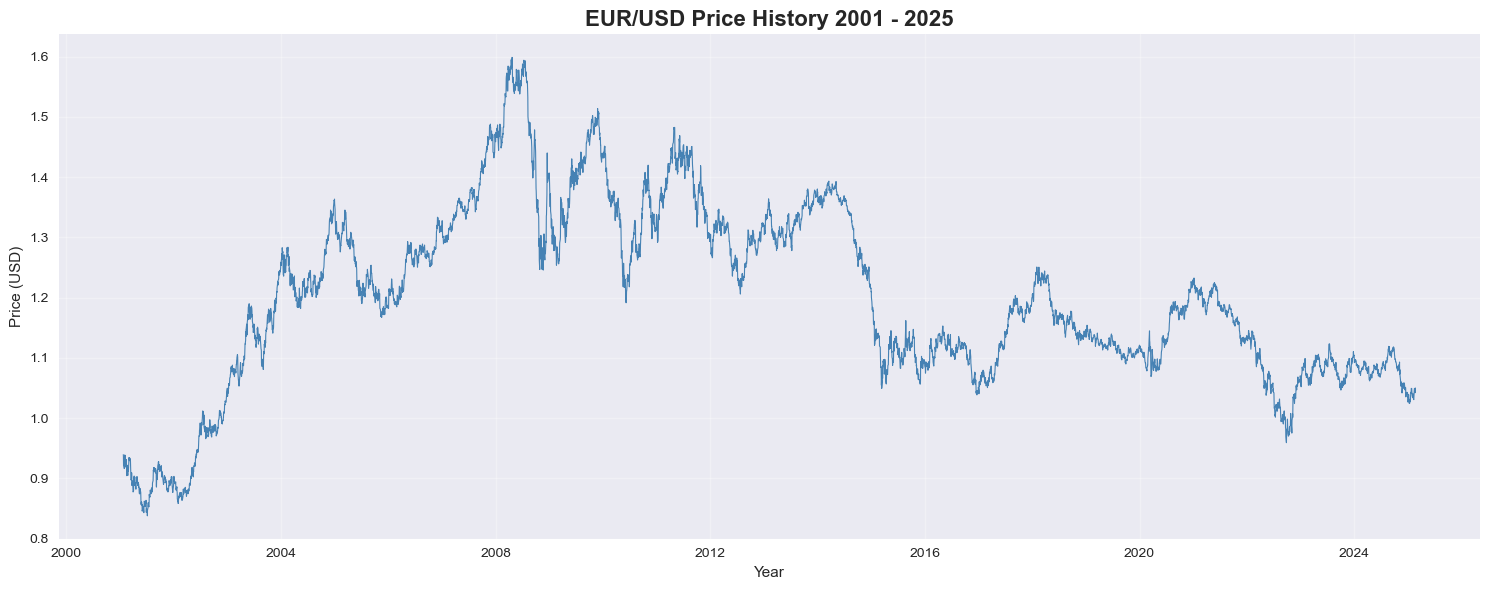

Date range: 2001-01-22 00:00:00 to 2025-02-21 00:00:00


In [5]:
# convert date column and sort from oldest to newest
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date').reset_index(drop=True)

# plot the full price history
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8)
plt.title('EUR/USD Price History 2001 - 2025', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Date range:", df['Date'].min(), "to", df['Date'].max())

In [6]:
# removing duplicate dates from the dataset
print("Shape before:", df.shape)

df = df.drop_duplicates(subset='Date', keep='first')
df = df.reset_index(drop=True)

print("Shape after:", df.shape)
print("Duplicates remaining:", df['Date'].duplicated().sum())
print("Duplicates removed successfully!")

Shape before: (11284, 7)
Shape after: (6284, 7)
Duplicates remaining: 0
Duplicates removed successfully!


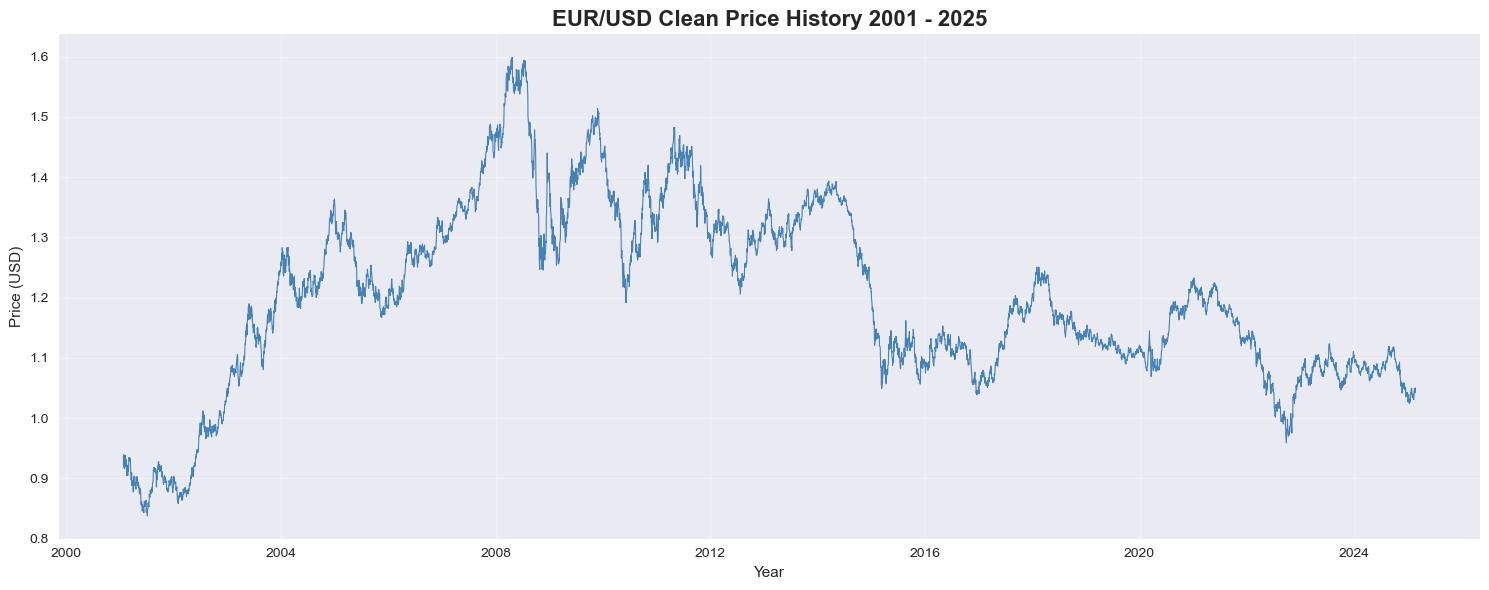

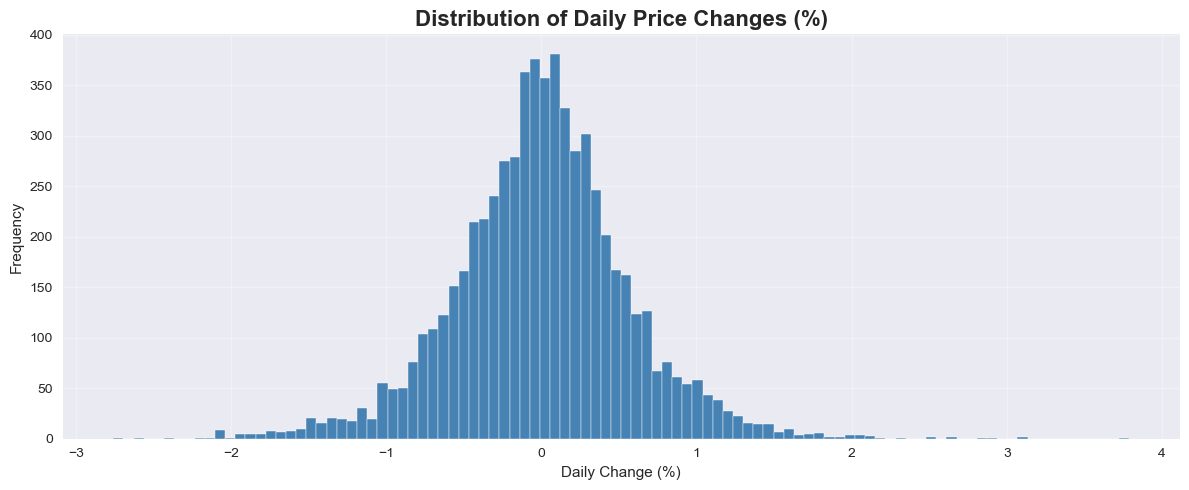

Average daily change: 0.0034 %
Max single day gain: 3.7888 %
Max single day loss: -2.7581 %


In [7]:
# plot clean price history
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8)
plt.title('EUR/USD Clean Price History 2001 - 2025', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# calculate and plot daily price changes
df['Daily_Change'] = df['Price'].pct_change() * 100

plt.figure(figsize=(12, 5))
plt.hist(df['Daily_Change'].dropna(), bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution of Daily Price Changes (%)', fontsize=16, fontweight='bold')
plt.xlabel('Daily Change (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average daily change:", round(df['Daily_Change'].mean(), 4), "%")
print("Max single day gain:", round(df['Daily_Change'].max(), 4), "%")
print("Max single day loss:", round(df['Daily_Change'].min(), 4), "%")

In [8]:
# drop the empty volume column and fix the change % column
df = df.drop(columns=['Vol.'])
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

print("Columns now:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nVolume dropped and Change % fixed!")

Columns now: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %', 'Daily_Change']

Data types:
Date            datetime64[ns]
Price                  float64
Open                   float64
High                   float64
Low                    float64
Change %               float64
Daily_Change           float64
dtype: object

First 5 rows:
        Date   Price    Open    High     Low  Change %  Daily_Change
0 2001-01-22  0.9393  0.9342  0.9406  0.9270      0.61           NaN
1 2001-01-23  0.9376  0.9392  0.9452  0.9370     -0.18     -0.180986
2 2001-01-24  0.9210  0.9374  0.9380  0.9213     -1.77     -1.770478
3 2001-01-25  0.9242  0.9218  0.9253  0.9111      0.35      0.347448
4 2001-01-26  0.9238  0.9244  0.9319  0.9196     -0.04     -0.043281

Volume dropped and Change % fixed!


In [9]:
# creating my target variables
# 1 = price goes up, 0 = price goes down
df['Target_Direction'] = (df['Price'].shift(-1) > df['Price']).astype(int)
df['Target_Price'] = df['Price'].shift(-1)
df = df[:-1].reset_index(drop=True)

print(df[['Date', 'Price', 'Target_Direction', 'Target_Price']].head(10))
print("\nUP days:", df['Target_Direction'].sum())
print("DOWN days:", (df['Target_Direction'] == 0).sum())
print("Target variables created!")

        Date   Price  Target_Direction  Target_Price
0 2001-01-22  0.9393                 0        0.9376
1 2001-01-23  0.9376                 0        0.9210
2 2001-01-24  0.9210                 1        0.9242
3 2001-01-25  0.9242                 0        0.9238
4 2001-01-26  0.9238                 0        0.9162
5 2001-01-29  0.9162                 1        0.9265
6 2001-01-30  0.9265                 1        0.9362
7 2001-01-31  0.9362                 1        0.9388
8 2001-02-01  0.9388                 0        0.9360
9 2001-02-02  0.9360                 1        0.9380

UP days: 3145
DOWN days: 3138
Target variables created!


In [10]:
# final check before saving
print("Missing values:")
print(df.isnull().sum())

print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nDate range:")
print("From:", df['Date'].min().strftime('%d %B %Y'))
print("To:", df['Date'].max().strftime('%d %B %Y'))

# save the clean dataset
df.to_csv('EUR_USD_Clean.csv', index=False)
print("\nClean dataset saved!")

Missing values:
Date                0
Price               0
Open                0
High                0
Low                 0
Change %            0
Daily_Change        1
Target_Direction    0
Target_Price        0
dtype: int64

Shape: (6283, 9)
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %', 'Daily_Change', 'Target_Direction', 'Target_Price']

Date range:
From: 22 January 2001
To: 20 February 2025

Clean dataset saved!


In [11]:
# fix the one missing value in Daily_Change
df['Daily_Change'] = df['Daily_Change'].fillna(0)

print("Missing values after fix:")
print(df.isnull().sum())

df.to_csv('EUR_USD_Clean.csv', index=False)
print("Fixed and saved!")

Missing values after fix:
Date                0
Price               0
Open                0
High                0
Low                 0
Change %            0
Daily_Change        0
Target_Direction    0
Target_Price        0
dtype: int64
Fixed and saved!


In [12]:
# importing libraries and loading clean dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

df = pd.read_csv('EUR_USD_Clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Clean dataset loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Clean dataset loaded!
Shape: (6283, 9)
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %', 'Daily_Change', 'Target_Direction', 'Target_Price']


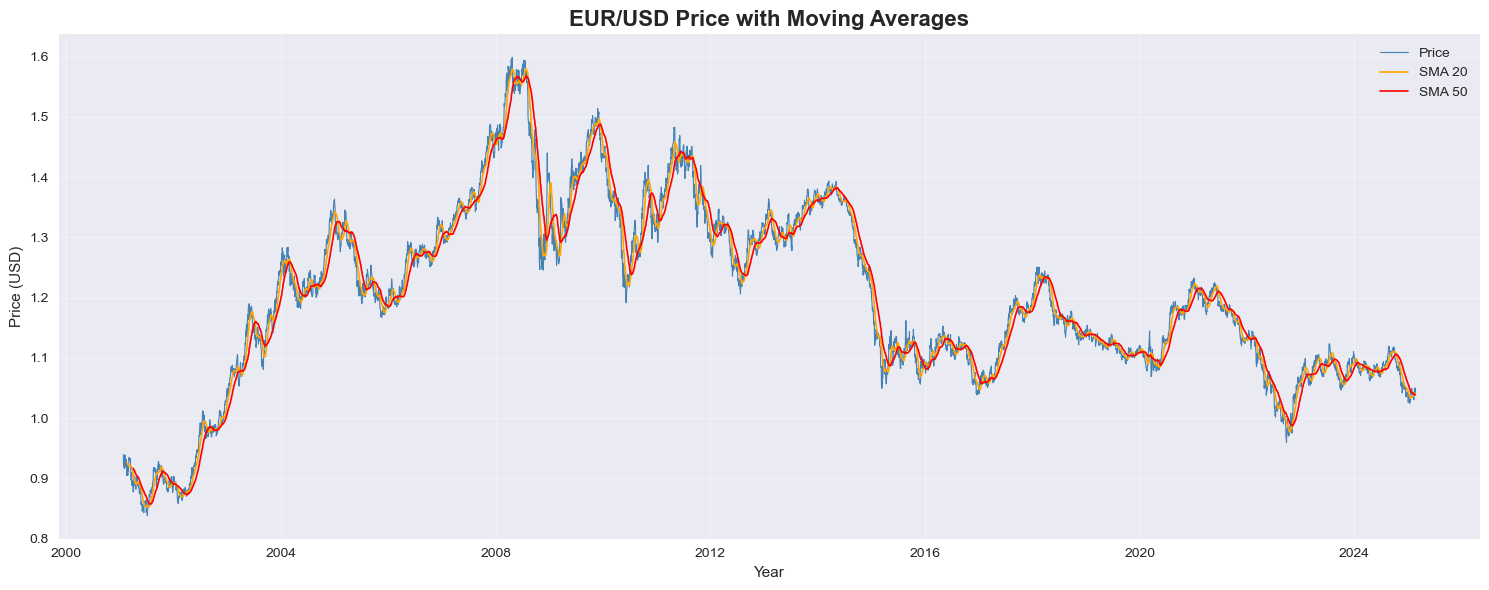

Moving Averages created!
           Date   Price   SMA_10    SMA_20    SMA_50    EMA_10    EMA_20  \
6278 2025-02-14  1.0491  1.03834  1.040415  1.039014  1.040383  1.039206   
6279 2025-02-17  1.0482  1.03972  1.040755  1.038874  1.041805  1.040062   
6280 2025-02-18  1.0445  1.04040  1.040835  1.038712  1.042295  1.040485   
6281 2025-02-19  1.0421  1.04059  1.040905  1.038566  1.042259  1.040639   
6282 2025-02-20  1.0500  1.04178  1.041330  1.038632  1.043667  1.041530   

        EMA_50  
6278  1.042865  
6279  1.043074  
6280  1.043130  
6281  1.043090  
6282  1.043361  


In [13]:
# calculating simple and exponential moving averages
df['SMA_10'] = df['Price'].rolling(window=10).mean()
df['SMA_20'] = df['Price'].rolling(window=20).mean()
df['SMA_50'] = df['Price'].rolling(window=50).mean()

df['EMA_10'] = df['Price'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['Price'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['Price'].ewm(span=50, adjust=False).mean()

# plot price with moving averages
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8, label='Price')
plt.plot(df['Date'], df['SMA_20'], color='orange', linewidth=1.2, label='SMA 20')
plt.plot(df['Date'], df['SMA_50'], color='red', linewidth=1.2, label='SMA 50')
plt.title('EUR/USD Price with Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Moving Averages created!")
print(df[['Date', 'Price', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_10', 'EMA_20', 'EMA_50']].tail())

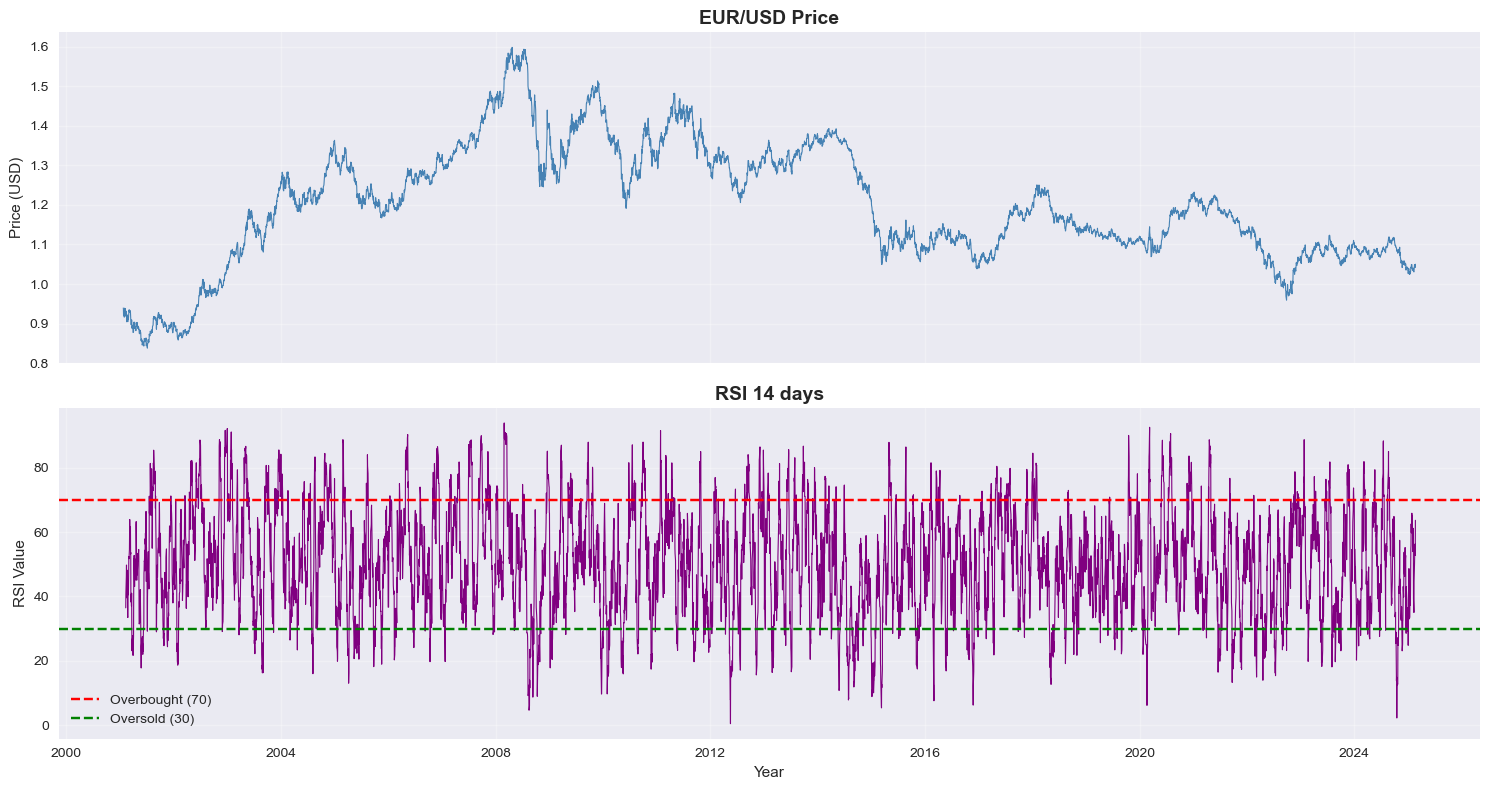

RSI created!
           Date   Price     RSI_14
6278 2025-02-14  1.0491  50.000000
6279 2025-02-17  1.0482  56.250000
6280 2025-02-18  1.0445  52.711497
6281 2025-02-19  1.0421  53.406593
6282 2025-02-20  1.0500  63.636364


In [14]:
# calculating RSI - shows overbought (above 70) or oversold (below 30)
delta = df['Price'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# plot price and RSI together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8)
ax1.set_title('EUR/USD Price', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.plot(df['Date'], df['RSI_14'], color='purple', linewidth=0.8)
ax2.axhline(y=70, color='red', linestyle='--', label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', label='Oversold (30)')
ax2.set_title('RSI 14 days', fontsize=14, fontweight='bold')
ax2.set_ylabel('RSI Value')
ax2.set_xlabel('Year')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("RSI created!")
print(df[['Date', 'Price', 'RSI_14']].tail())

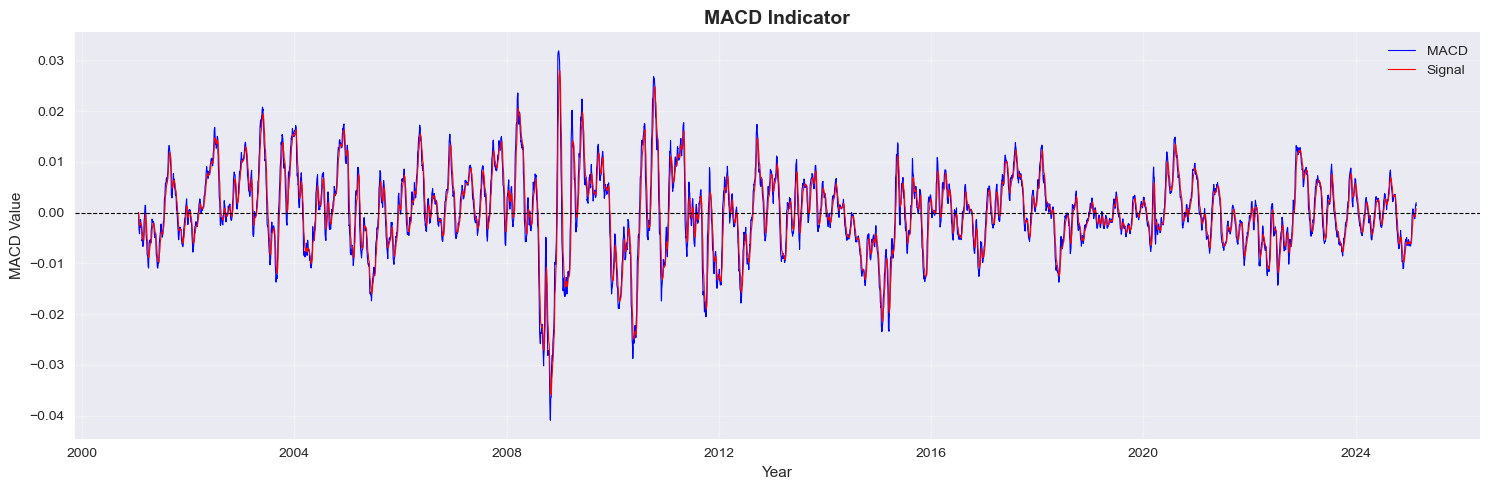

MACD created!


In [15]:
# calculating MACD - shows momentum and trend direction
ema_fast = df['Price'].ewm(span=12, adjust=False).mean()
ema_slow = df['Price'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_fast - ema_slow
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# plot MACD
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['MACD'], color='blue', linewidth=0.8, label='MACD')
plt.plot(df['Date'], df['MACD_Signal'], color='red', linewidth=0.8, label='Signal')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('MACD Indicator', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('MACD Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("MACD created!")

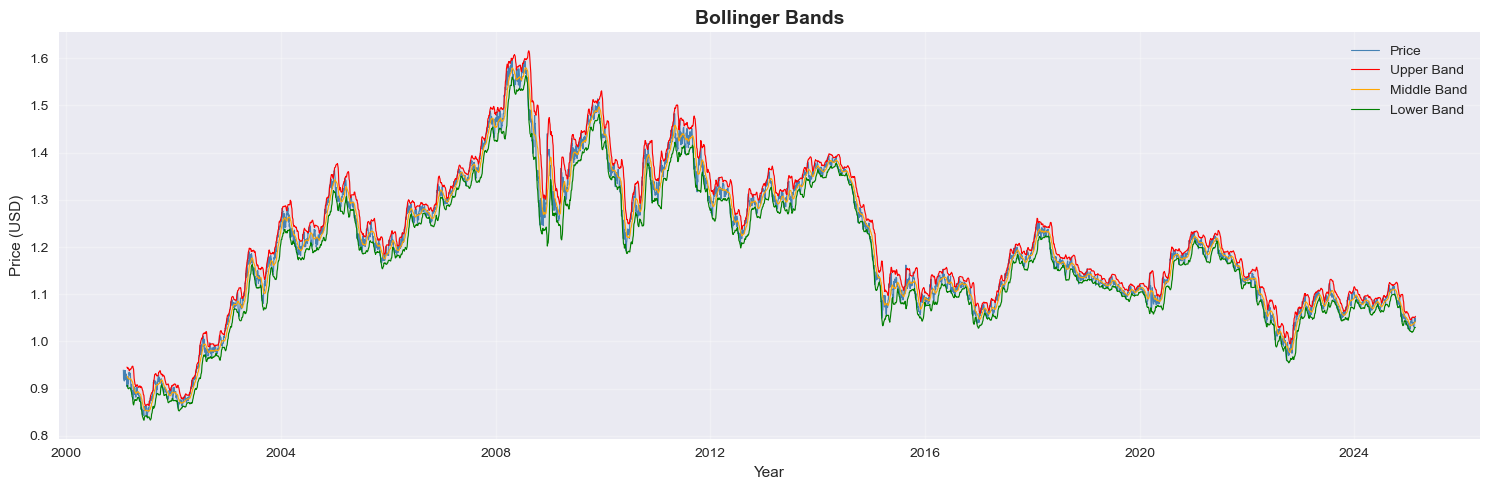

Bollinger Bands created!


In [16]:
# calculating bollinger bands - shows price volatility
df['BB_Middle'] = df['Price'].rolling(window=20).mean()
df['BB_Upper'] = df['BB_Middle'] + 2 * df['Price'].rolling(window=20).std()
df['BB_Lower'] = df['BB_Middle'] - 2 * df['Price'].rolling(window=20).std()

# plot bollinger bands
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8, label='Price')
plt.plot(df['Date'], df['BB_Upper'], color='red', linewidth=0.8, label='Upper Band')
plt.plot(df['Date'], df['BB_Middle'], color='orange', linewidth=0.8, label='Middle Band')
plt.plot(df['Date'], df['BB_Lower'], color='green', linewidth=0.8, label='Lower Band')
plt.fill_between(df['Date'], df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='grey')
plt.title('Bollinger Bands', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Bollinger Bands created!")

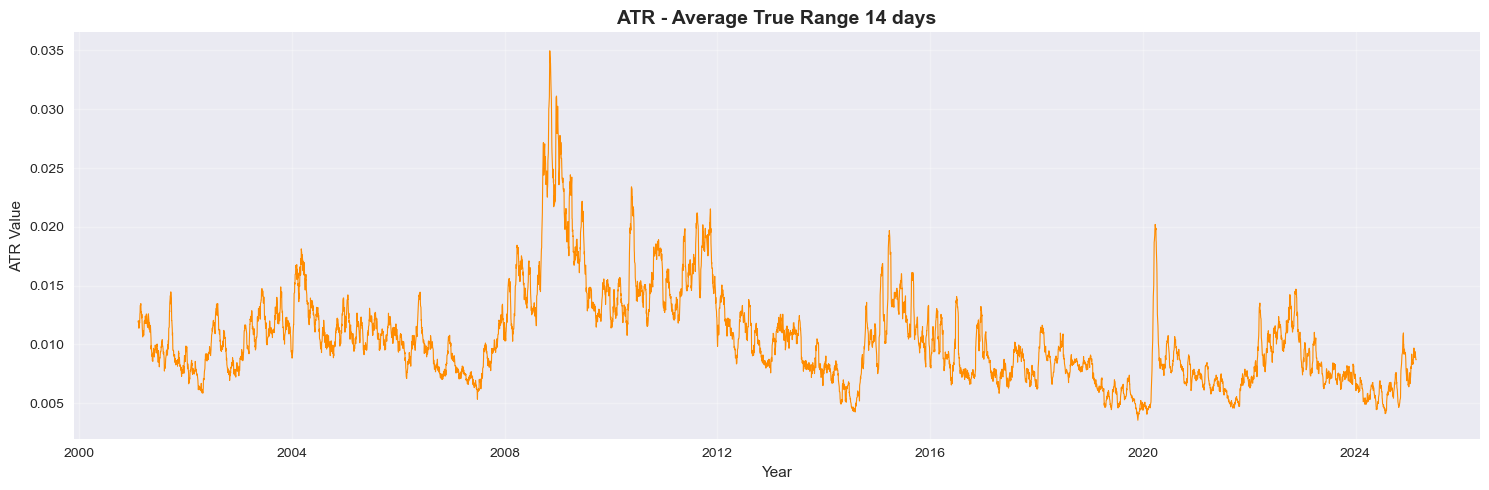

ATR created!


In [17]:
# calculating ATR - measures how much price moves each day
df['TR'] = df['High'] - df['Low']
df['ATR_14'] = df['TR'].rolling(window=14).mean()

# plot ATR
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['ATR_14'], color='darkorange', linewidth=0.8)
plt.title('ATR - Average True Range 14 days', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('ATR Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ATR created!")

In [18]:
# drop missing values and save final dataset
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values:", df.isnull().sum().sum())

df.to_csv('EUR_USD_Features.csv', index=False)
print("Features dataset saved!")

Final shape: (6234, 23)
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %', 'Daily_Change', 'Target_Direction', 'Target_Price', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_10', 'EMA_20', 'EMA_50', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'TR', 'ATR_14']
Missing values: 0
Features dataset saved!


In [19]:
# importing libraries needed for model building
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load the features dataset
df = pd.read_csv('EUR_USD_Features.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (6234, 23)


In [20]:
# selecting features and target variable
features = ['Open', 'High', 'Low', 'Change %', 'Daily_Change',
            'SMA_10', 'SMA_20', 'SMA_50',
            'EMA_10', 'EMA_20', 'EMA_50',
            'RSI_14', 'MACD', 'MACD_Signal',
            'BB_Upper', 'BB_Middle', 'BB_Lower',
            'ATR_14']

X = df[features]
y = df['Target_Direction']

# split 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Data ready!")

Training size: (4987, 18)
Testing size: (1247, 18)
Data ready!


In [21]:
# model 1 - logistic regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 52.21 %
              precision    recall  f1-score   support

           0       0.55      0.36      0.44       635
           1       0.51      0.69      0.59       612

    accuracy                           0.52      1247
   macro avg       0.53      0.53      0.51      1247
weighted avg       0.53      0.52      0.51      1247



In [22]:
# model 2 - random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 49.48 %
              precision    recall  f1-score   support

           0       0.51      0.37      0.43       635
           1       0.49      0.62      0.55       612

    accuracy                           0.49      1247
   macro avg       0.50      0.50      0.49      1247
weighted avg       0.50      0.49      0.49      1247



In [23]:
# model 3 - xgboost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", round(xgb_accuracy * 100, 2), "%")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 49.64 %
              precision    recall  f1-score   support

           0       0.51      0.39      0.44       635
           1       0.49      0.61      0.54       612

    accuracy                           0.50      1247
   macro avg       0.50      0.50      0.49      1247
weighted avg       0.50      0.50      0.49      1247



In [24]:
# model 4 - support vector machine
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 51.48 %
              precision    recall  f1-score   support

           0       0.53      0.49      0.51       635
           1       0.51      0.54      0.52       612

    accuracy                           0.51      1247
   macro avg       0.52      0.52      0.51      1247
weighted avg       0.52      0.51      0.51      1247



Logistic Regression : 52.21 %
Random Forest : 49.48 %
XGBoost : 49.64 %
SVM : 51.48 %


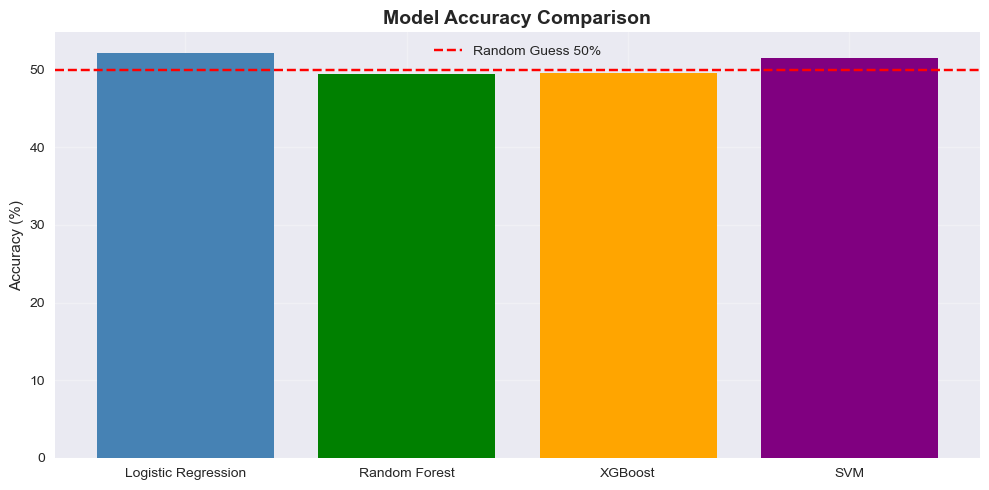

In [25]:
# comparing all 4 models
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']
accuracies = [lr_accuracy*100, rf_accuracy*100, xgb_accuracy*100, svm_accuracy*100]

for model, acc in zip(models, accuracies):
    print(model, ":", round(acc, 2), "%")

# plot comparison
plt.figure(figsize=(10, 5))
plt.bar(models, accuracies, color=['steelblue', 'green', 'orange', 'purple'])
plt.axhline(y=50, color='red', linestyle='--', label='Random Guess 50%')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# checking tensorflow version
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [27]:
# importing lstm libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# creating sequences of 10 days for lstm
sequence_length = 10
X_seq, y_seq = [], []

for i in range(sequence_length, len(df)):
    X_seq.append(df[features].values[i-sequence_length:i])
    y_seq.append(df['Target_Direction'].values[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# split 80% training and 20% testing
split = int(len(X_seq) * 0.8)
X_train_lstm = X_seq[:split]
X_test_lstm  = X_seq[split:]
y_train_lstm = y_seq[:split]
y_test_lstm  = y_seq[split:]

print("Training shape:", X_train_lstm.shape)
print("Testing shape:", X_test_lstm.shape)
print("LSTM data ready!")

Training shape: (4979, 10, 18)
Testing shape: (1245, 10, 18)
LSTM data ready!


In [28]:
# building and training the lstm model
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(10, 18)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training LSTM - please wait...")
history = model.fit(X_train_lstm, y_train_lstm,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=1)

print("LSTM training complete!")

C:\Users\shime\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM - please wait...
Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4939 - loss: 0.7058 - val_accuracy: 0.5201 - val_loss: 0.6939
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4972 - loss: 0.7027 - val_accuracy: 0.5201 - val_loss: 0.6947
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5066 - loss: 0.6975 - val_accuracy: 0.4679 - val_loss: 0.6957
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5032 - loss: 0.6974 - val_accuracy: 0.5361 - val_loss: 0.6950
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4968 - loss: 0.6968 - val_accuracy: 0.4940 - val_loss: 0.6946
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5066 - loss: 0.6954 - val_accuracy: 0.4900 - val_loss: 0.6940
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5068 - loss: 0.6939 - val_accuracy: 0.4679 - val_loss: 0.6957
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5102 - 

In [31]:
# testing the lstm model
lstm_pred_prob = model.predict(X_test_lstm)
lstm_pred = (lstm_pred_prob > 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test_lstm, lstm_pred)
print("LSTM Accuracy:", round(lstm_accuracy * 100, 2), "%")
print(classification_report(y_test_lstm, lstm_pred))

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
LSTM Accuracy: 49.56 %
              precision    recall  f1-score   support

           0       0.52      0.16      0.24       634
           1       0.49      0.85      0.62       611

    accuracy                           0.50      1245
   macro avg       0.50      0.50      0.43      1245
weighted avg       0.50      0.50      0.43      1245



Logistic Regression : 52.21 %
Random Forest : 49.48 %
XGBoost : 49.64 %
SVM : 51.48 %
LSTM : 49.56 %


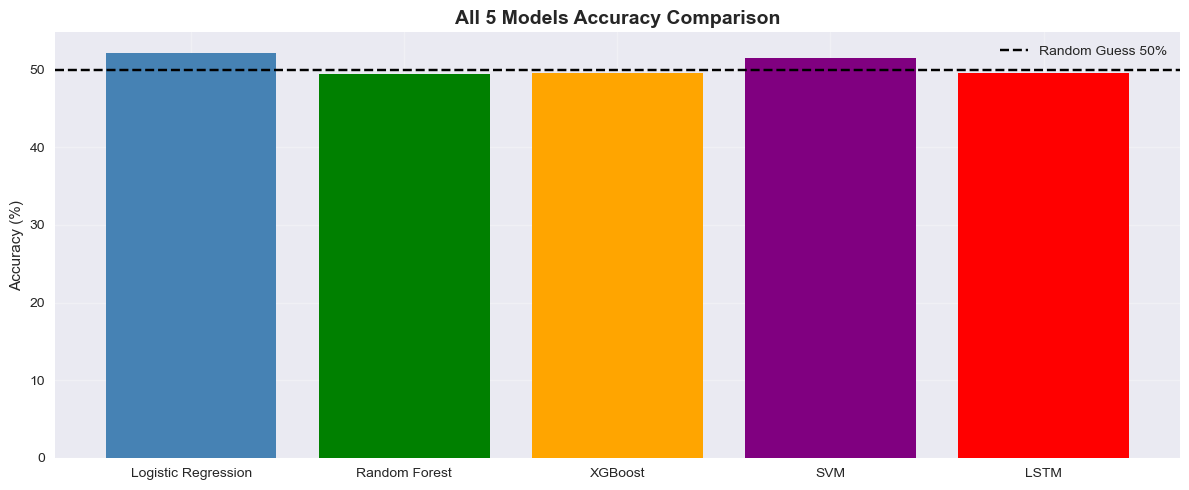

In [32]:
# comparing all 5 models including lstm
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM', 'LSTM']
accuracies = [lr_accuracy*100, rf_accuracy*100, xgb_accuracy*100, svm_accuracy*100, lstm_accuracy*100]

for model, acc in zip(models, accuracies):
    print(model, ":", round(acc, 2), "%")

# plot all 5 models
plt.figure(figsize=(12, 5))
plt.bar(models, accuracies, color=['steelblue', 'green', 'orange', 'purple', 'red'])
plt.axhline(y=50, color='black', linestyle='--', label='Random Guess 50%')
plt.title('All 5 Models Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

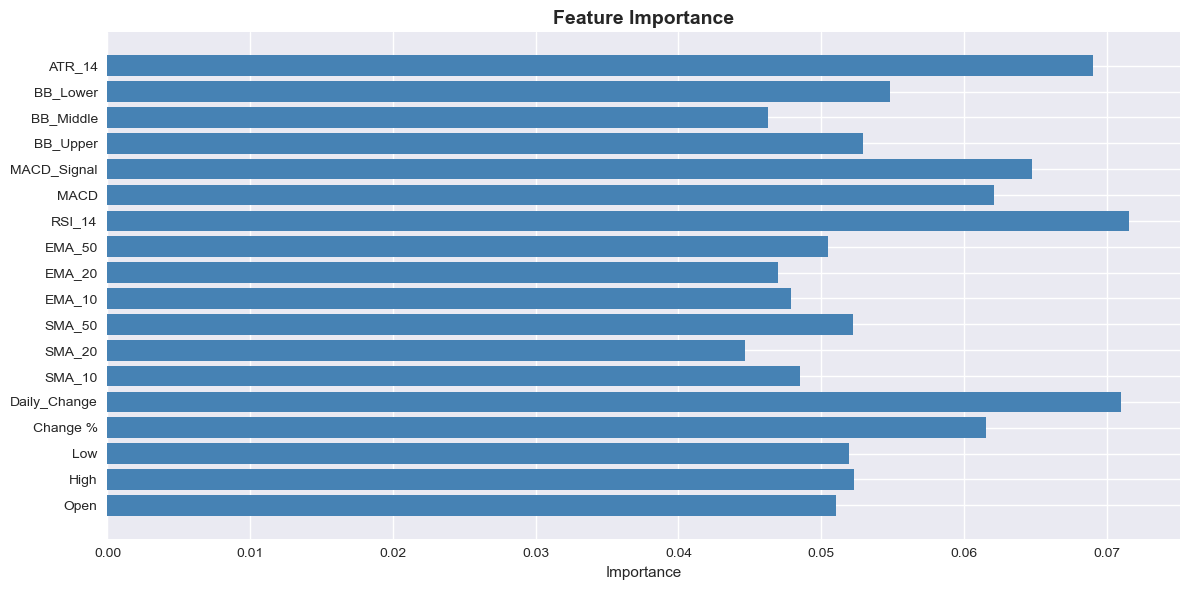

In [33]:
# which features helped the model most
importance = rf_model.feature_importances_

plt.figure(figsize=(12, 6))
plt.barh(features, importance, color='steelblue')
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

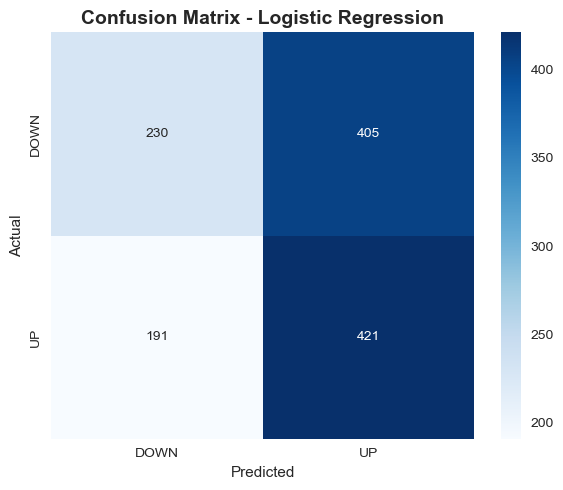

In [34]:
# confusion matrix for best model - logistic regression
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DOWN', 'UP'],
            yticklabels=['DOWN', 'UP'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

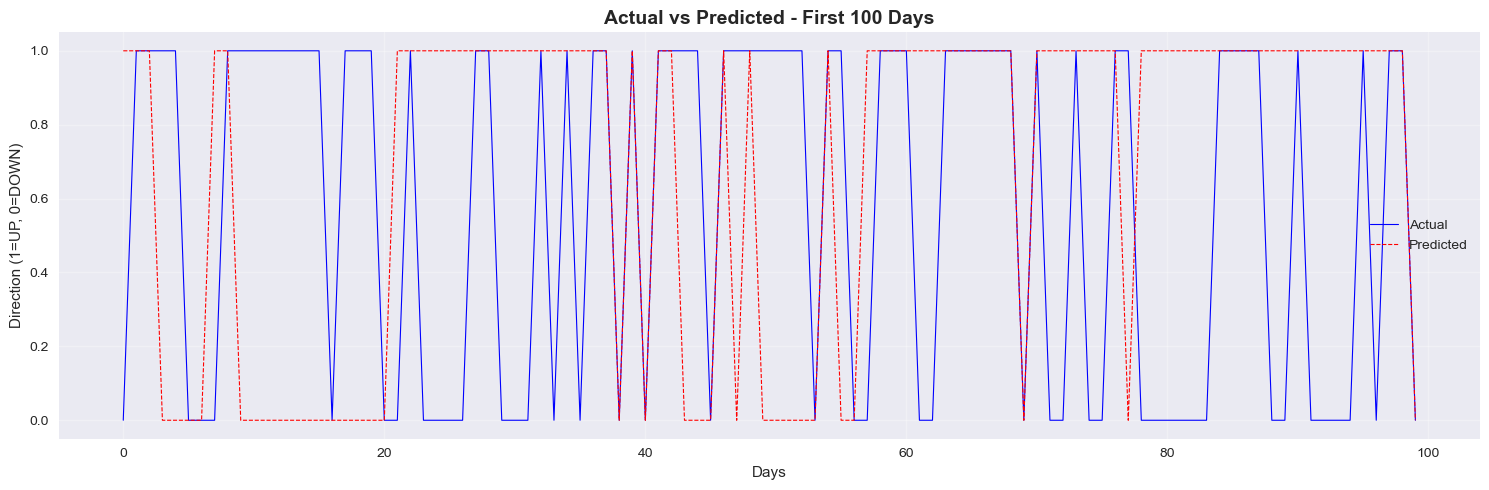

In [35]:
# predicted vs actual price direction
plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:100], color='blue', linewidth=0.8, label='Actual')
plt.plot(lr_pred[:100], color='red', linewidth=0.8, linestyle='--', label='Predicted')
plt.title('Actual vs Predicted - First 100 Days', fontsize=14, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Direction (1=UP, 0=DOWN)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# final results summary
print("Project Results Summary")
print("Logistic Regression :", round(lr_accuracy*100, 2), "% - Best")
print("SVM                 :", round(svm_accuracy*100, 2), "%")
print("XGBoost             :", round(xgb_accuracy*100, 2), "%")
print("Random Forest       :", round(rf_accuracy*100, 2), "%")
print("LSTM                :", round(lstm_accuracy*100, 2), "% - Worst")
print("Top features: Daily_Change, RSI_14, ATR_14")
print("Dataset: EUR/USD 2001-2025 from Kaggle")

Project Results Summary
Logistic Regression : 52.21 % - Best
SVM                 : 51.48 %
XGBoost             : 49.64 %
Random Forest       : 49.48 %
LSTM                : 49.56 % - Worst
Top features: Daily_Change, RSI_14, ATR_14
Dataset: EUR/USD 2001-2025 from Kaggle
